In [ ]:
from google.colab import drive
import os
import pandas as pd

# Mount Drive của bạn vào môi trường Colab
drive.mount('/content/drive')

# Đường dẫn đến thư mục .vnstock (hãy kiểm tra lại đường dẫn chính xác trong Drive của bạn)
# Thông thường sẽ là: /content/drive/MyDrive/.vnstock
folder_path = '/content/drive/MyDrive/ITEC 2/.vnstock'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


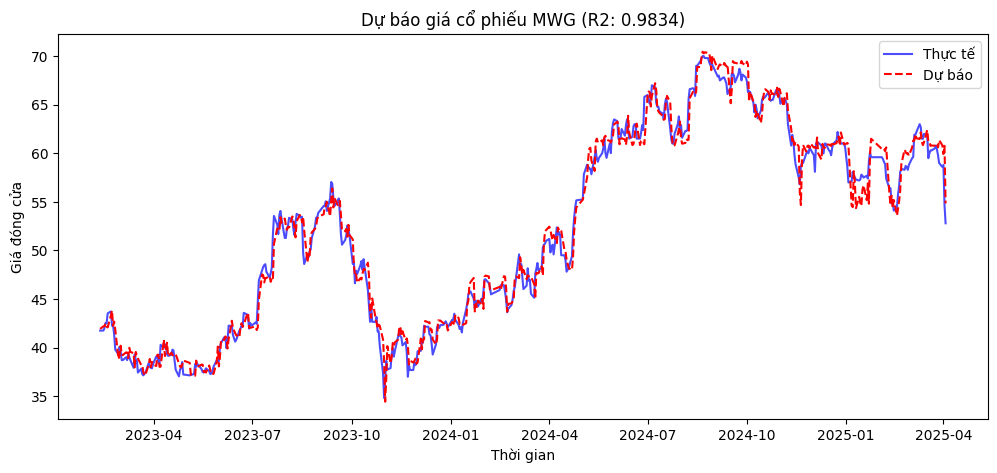

Hoàn thành: MWG | MAE: 0.98


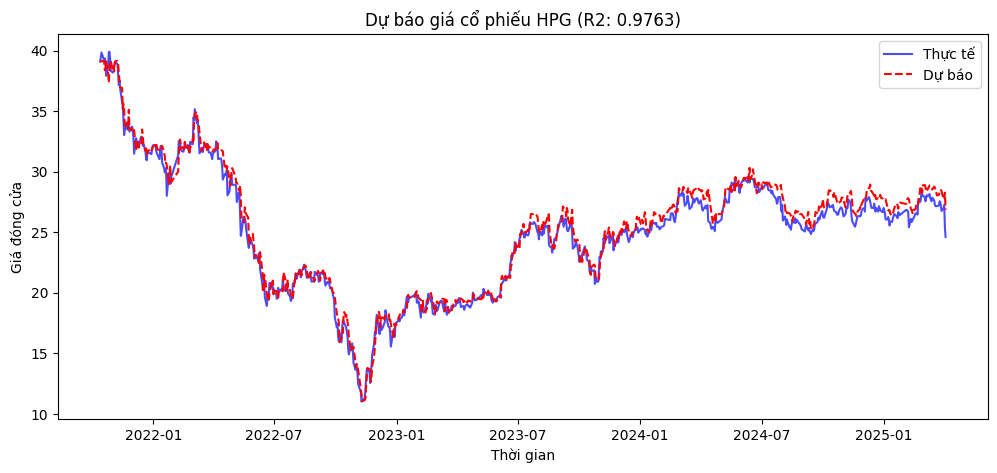

Hoàn thành: HPG | MAE: 0.63


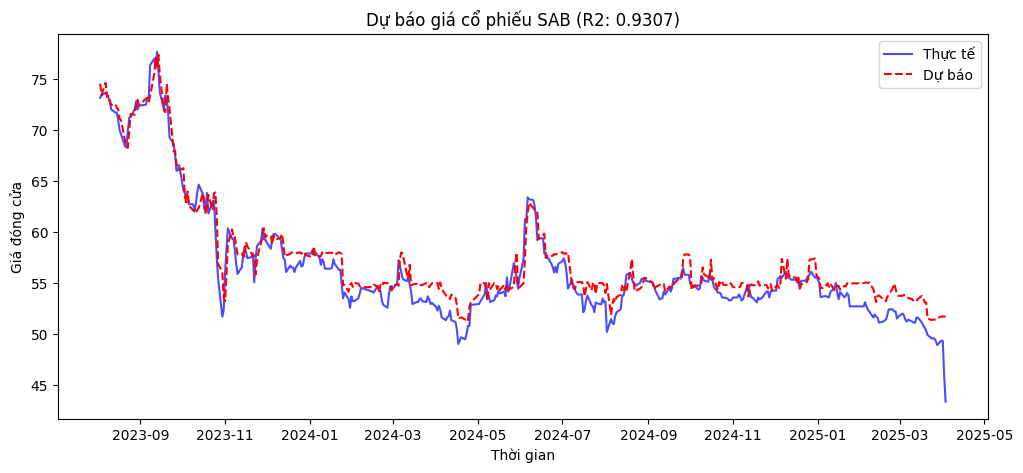

Hoàn thành: SAB | MAE: 1.23


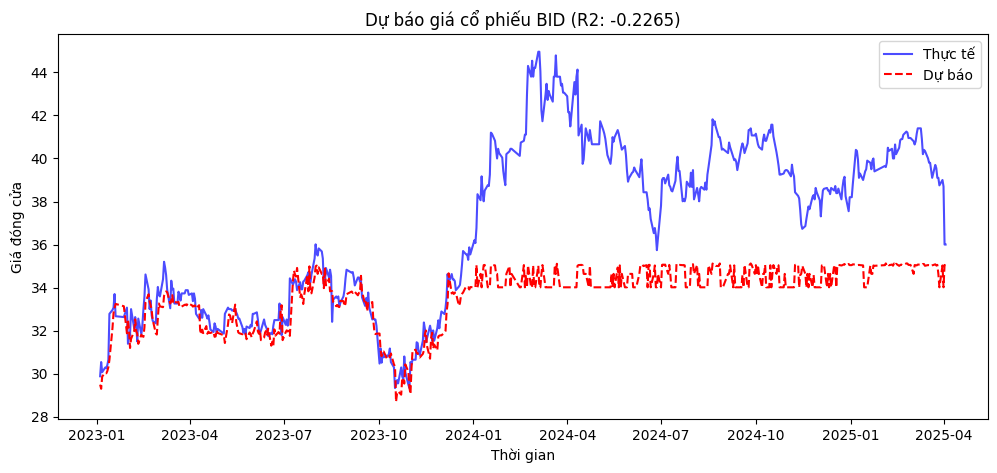

Hoàn thành: BID | MAE: 3.30
Bỏ qua: Không tìm thấy file cho VPL


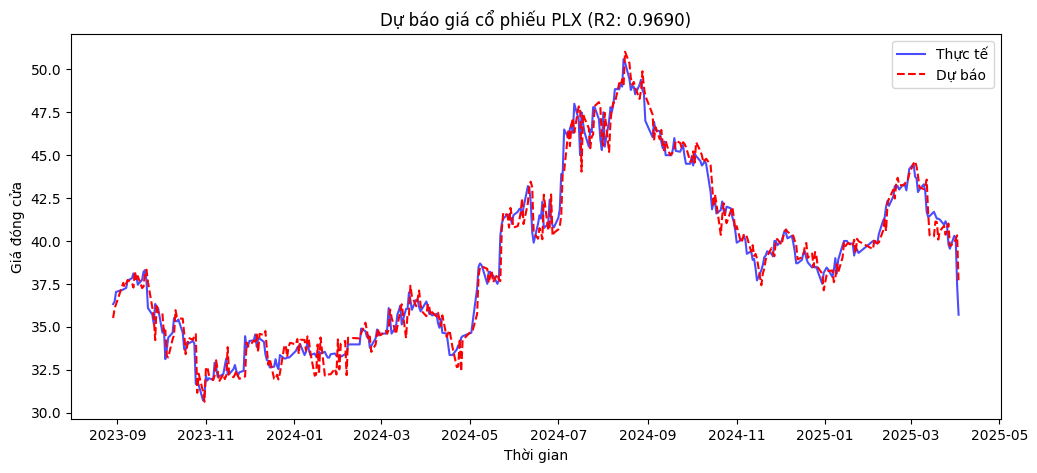

Hoàn thành: PLX | MAE: 0.64


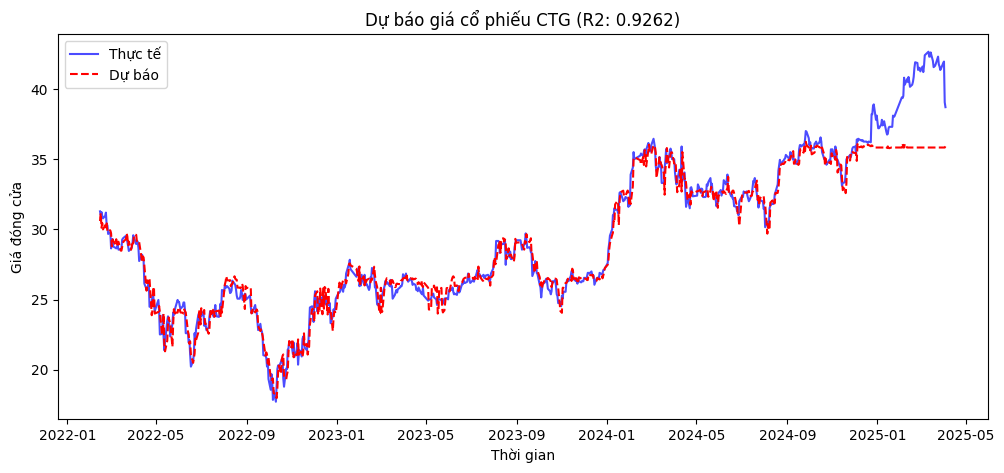

Hoàn thành: CTG | MAE: 0.82


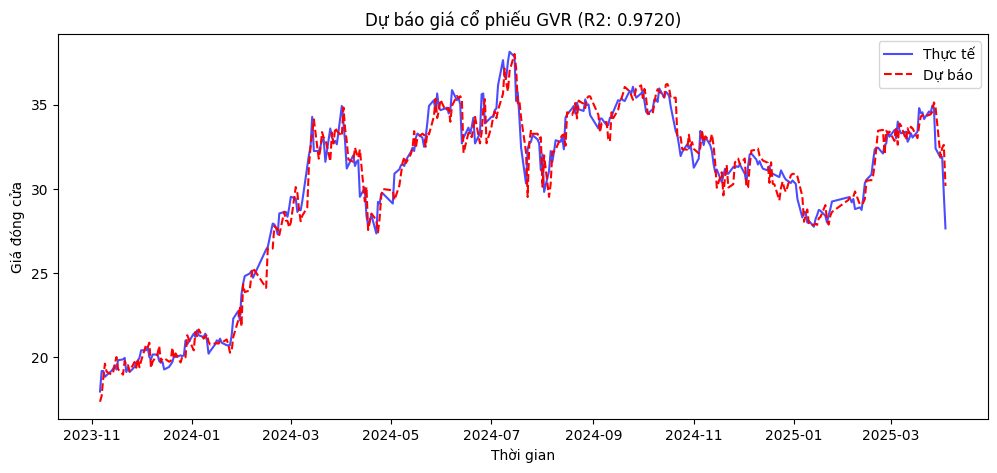

Hoàn thành: GVR | MAE: 0.64


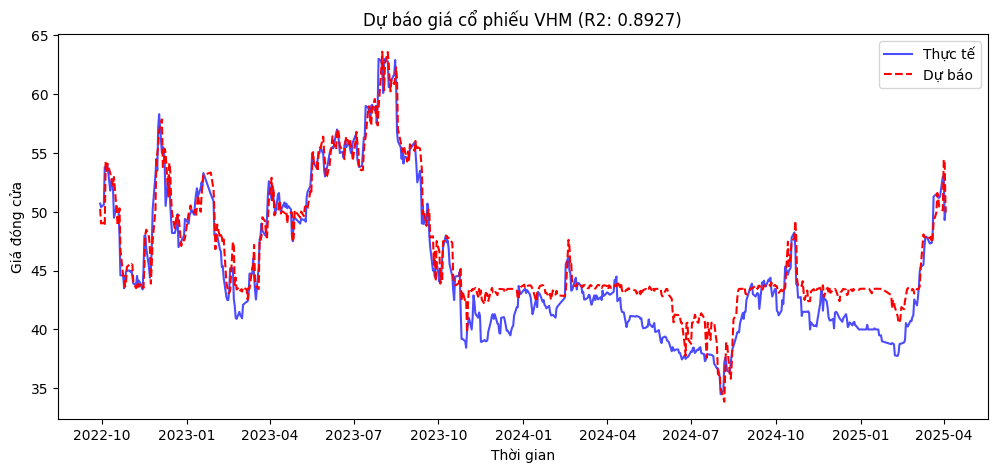

Hoàn thành: VHM | MAE: 1.61


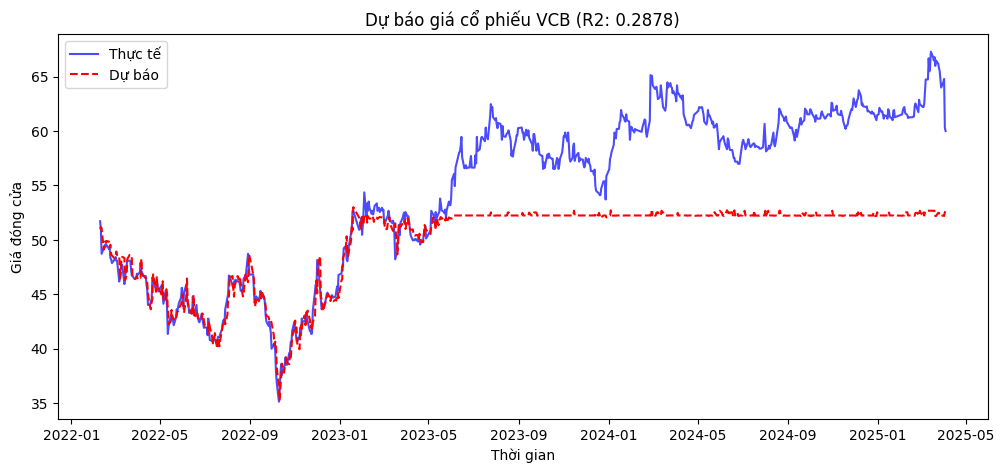

Hoàn thành: VCB | MAE: 4.93


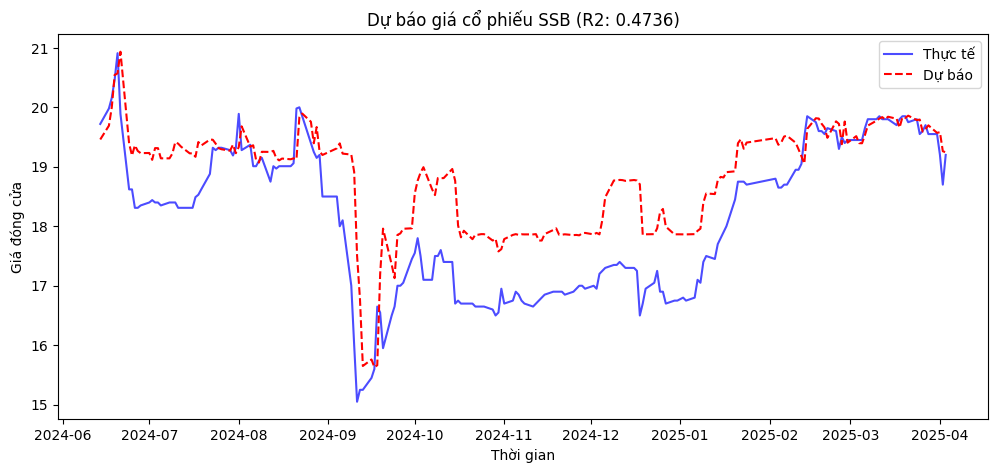

Hoàn thành: SSB | MAE: 0.74


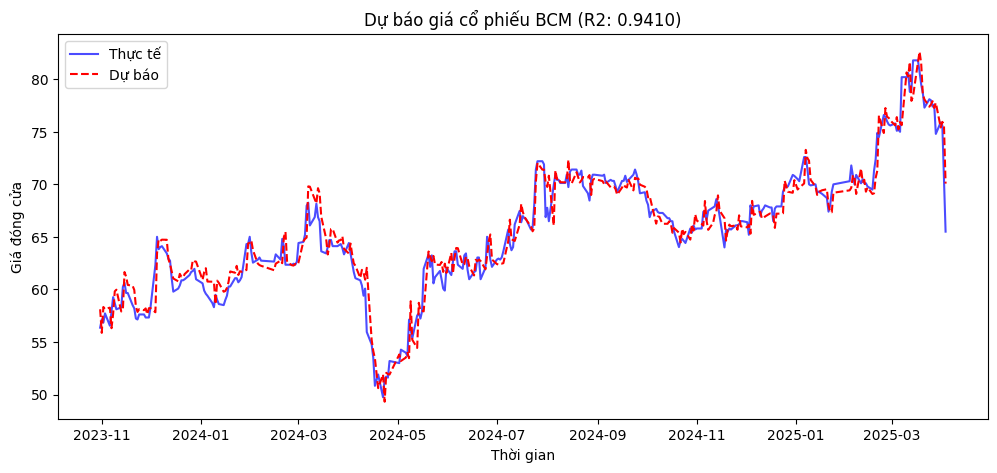

Hoàn thành: BCM | MAE: 1.07


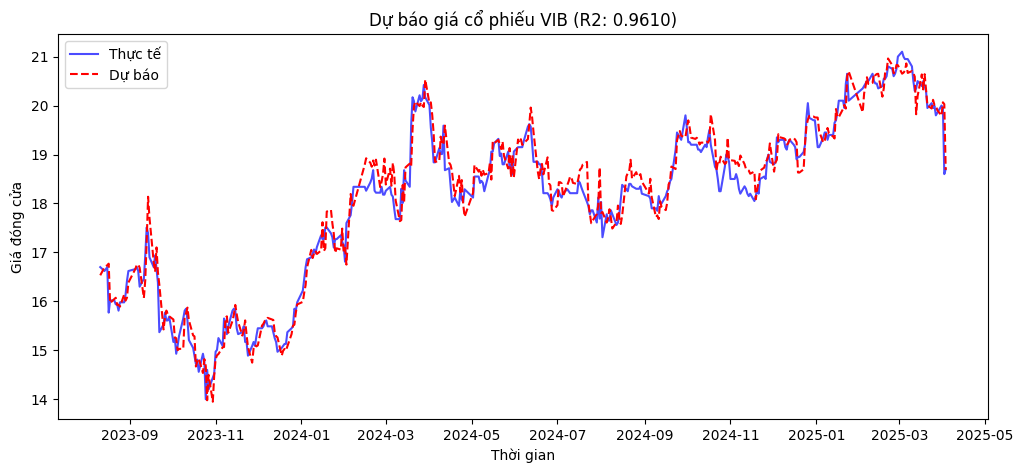

Hoàn thành: VIB | MAE: 0.25


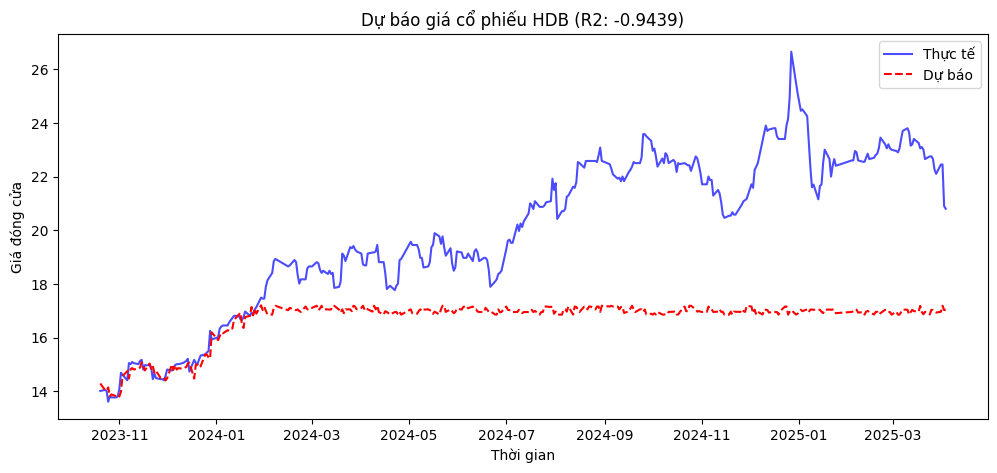

Hoàn thành: HDB | MAE: 3.30


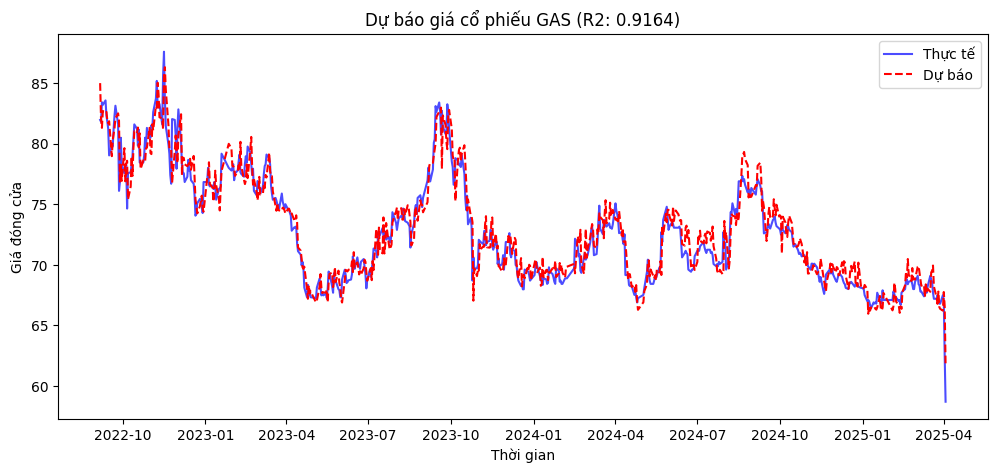

Hoàn thành: GAS | MAE: 0.99


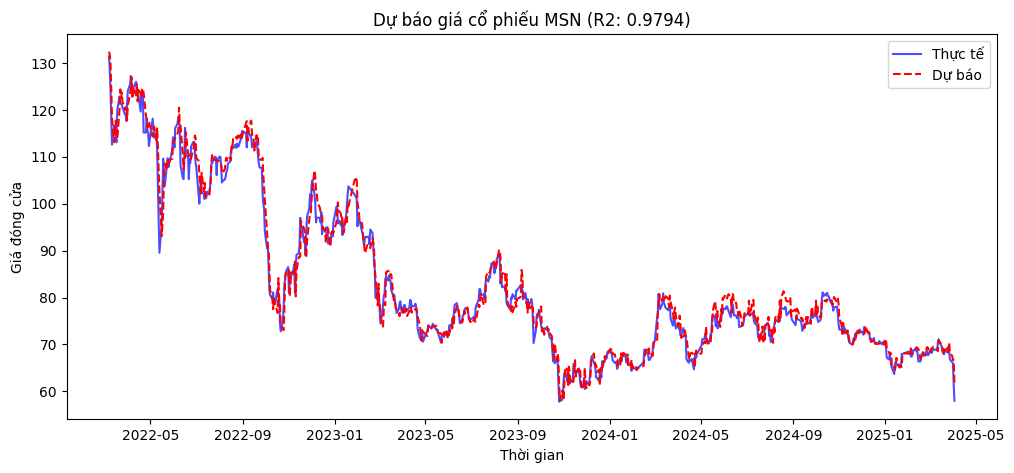

Hoàn thành: MSN | MAE: 1.71


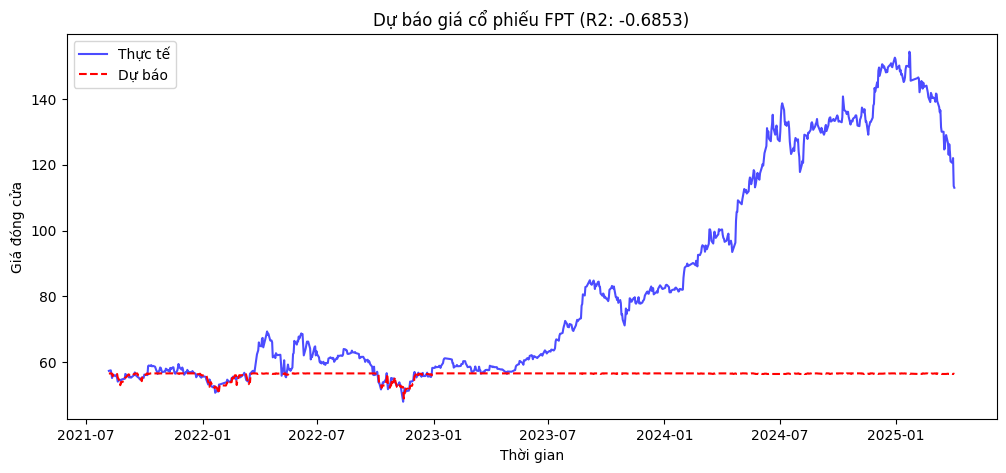

Hoàn thành: FPT | MAE: 26.92


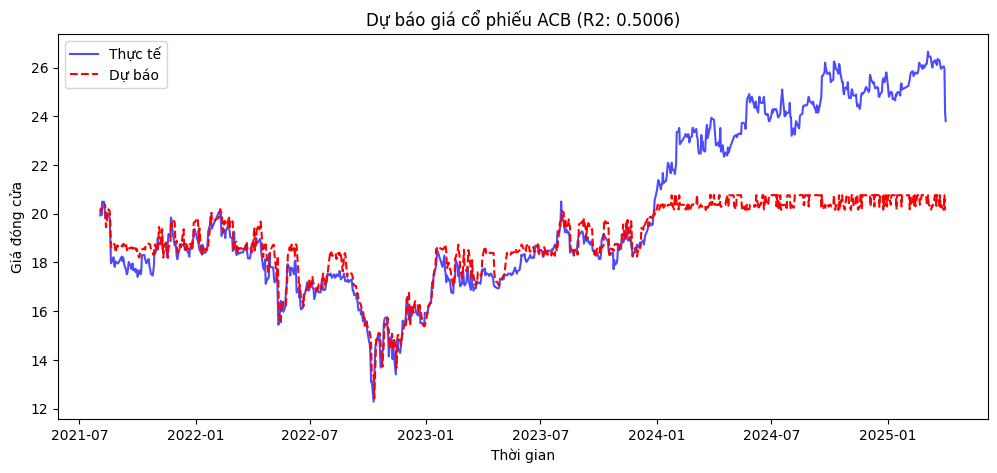

Hoàn thành: ACB | MAE: 1.59


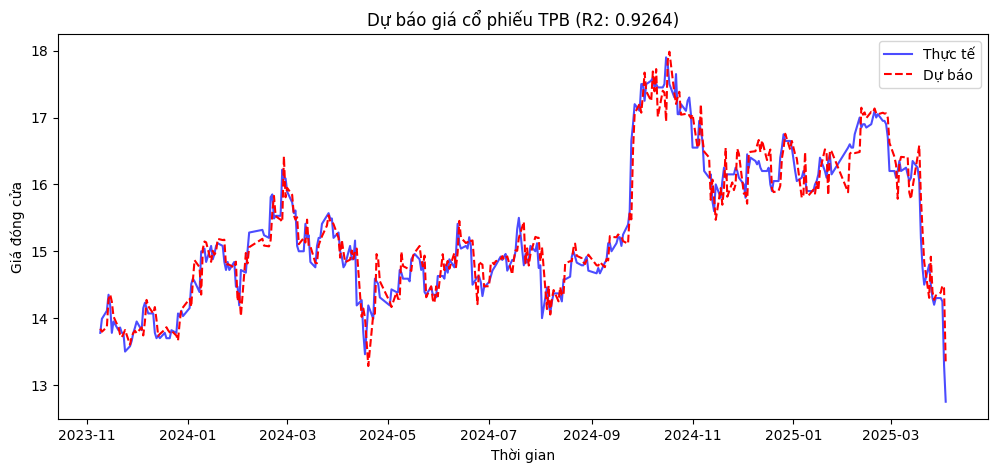

Hoàn thành: TPB | MAE: 0.21


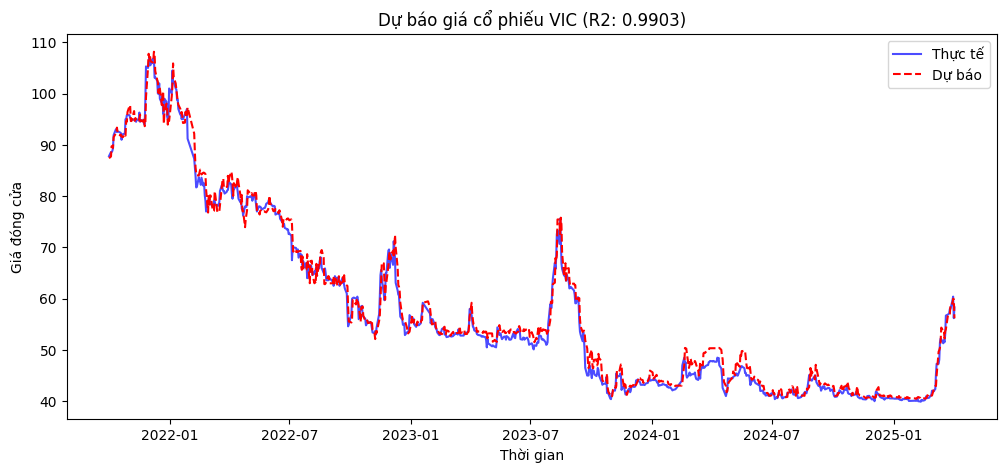

Hoàn thành: VIC | MAE: 1.26


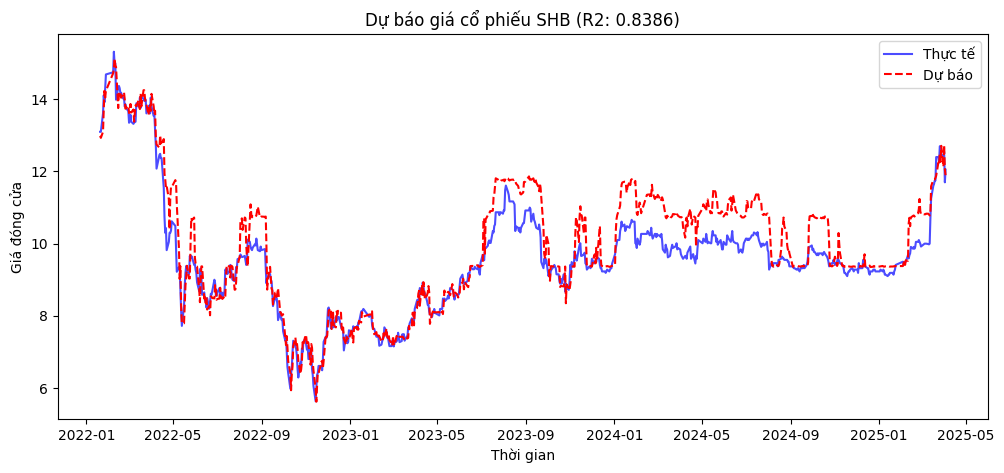

Hoàn thành: SHB | MAE: 0.48


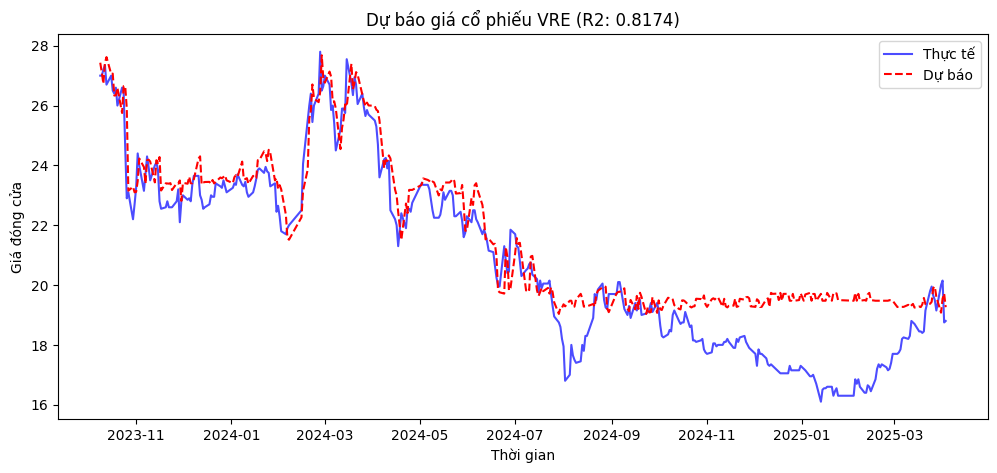

Hoàn thành: VRE | MAE: 0.99


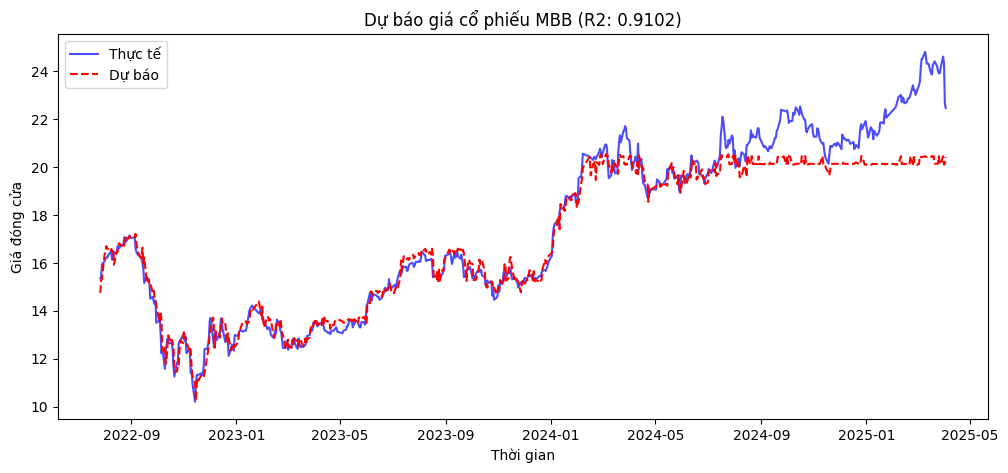

Hoàn thành: MBB | MAE: 0.66


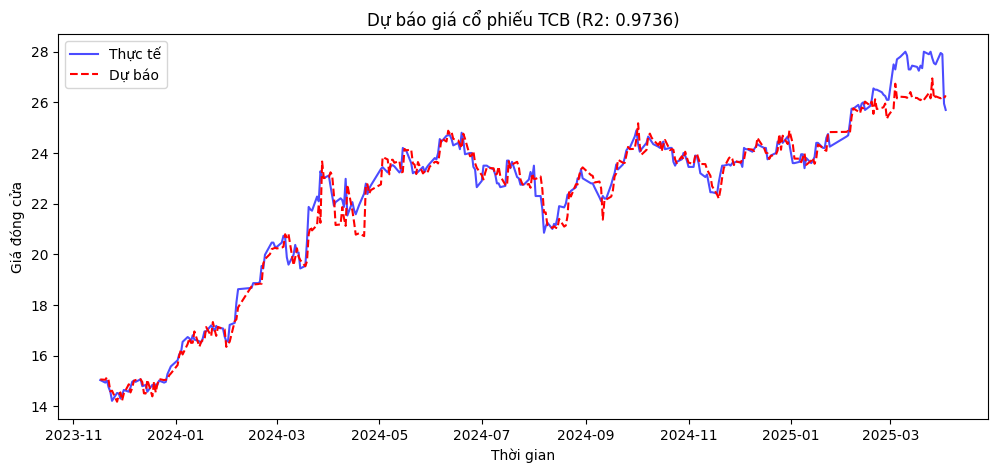

Hoàn thành: TCB | MAE: 0.38


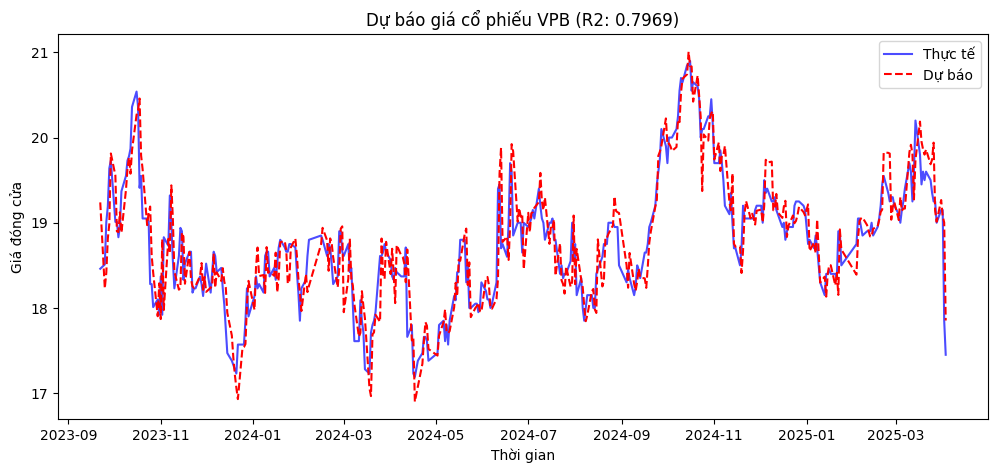

Hoàn thành: VPB | MAE: 0.24


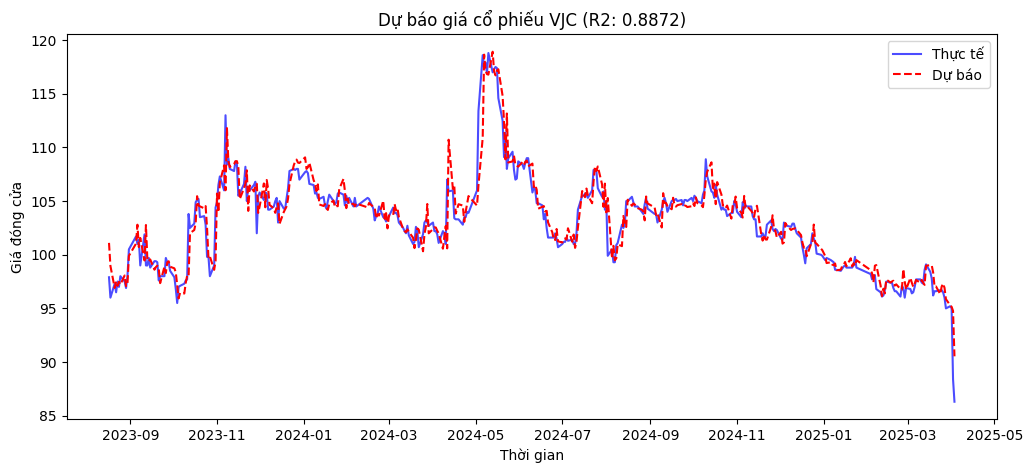

Hoàn thành: VJC | MAE: 0.94


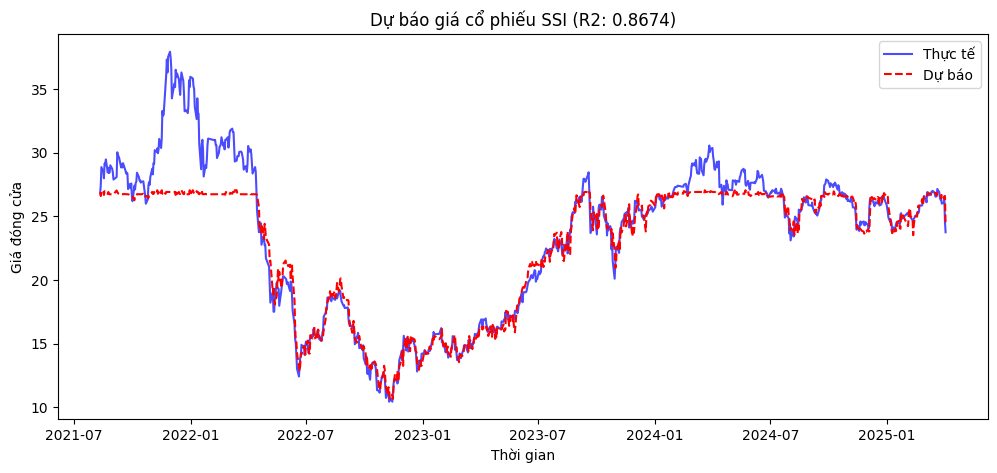

Hoàn thành: SSI | MAE: 1.22


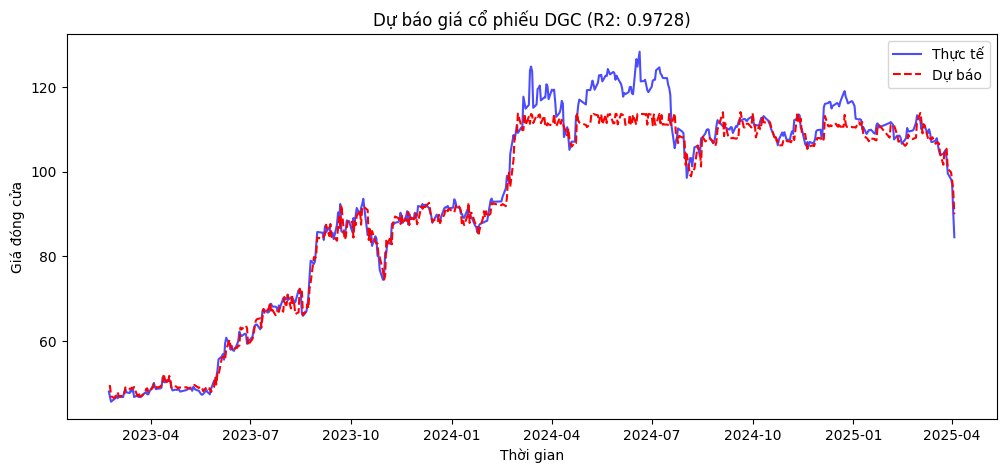

Hoàn thành: DGC | MAE: 2.72


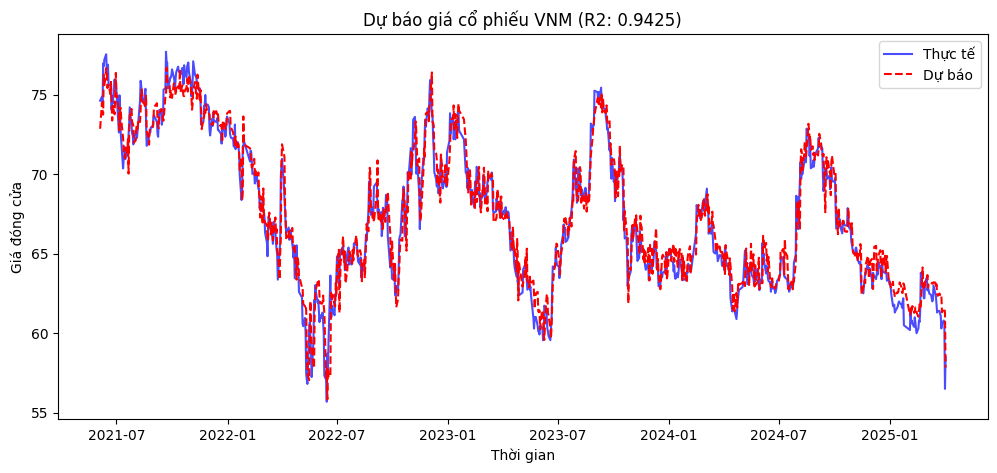

Hoàn thành: VNM | MAE: 0.85


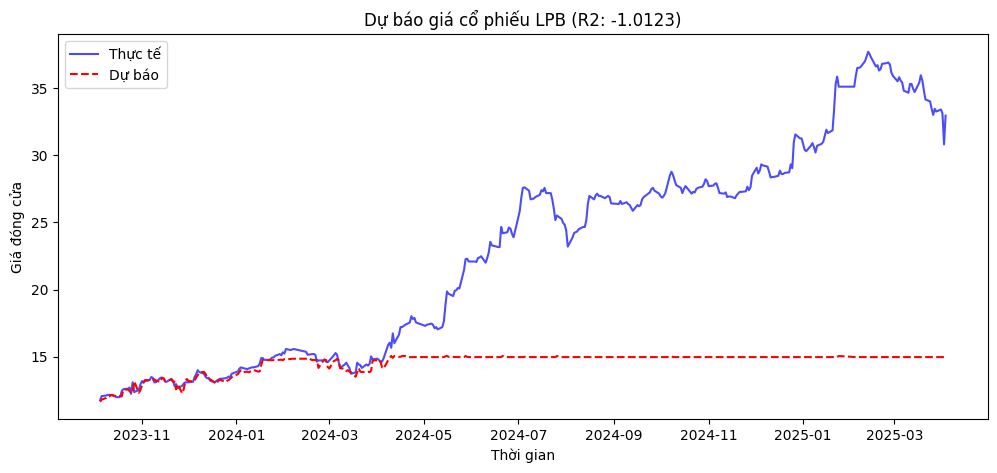

Hoàn thành: LPB | MAE: 8.30


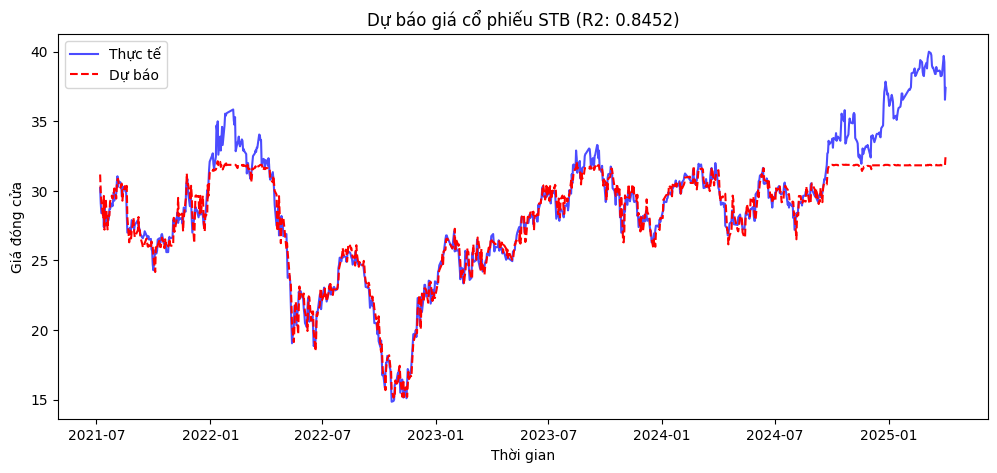

Hoàn thành: STB | MAE: 1.12

--- BẢNG TỔNG HỢP HIỆU SUẤT ---
   Symbol        MAE        R2
18    VIC   1.263466  0.990325
0     MWG   0.978556  0.983425
14    MSN   1.714961  0.979388
1     HPG   0.629164  0.976273
22    TCB   0.383982  0.973610
26    DGC   2.718079  0.972793
6     GVR   0.643710  0.972016
4     PLX   0.637551  0.968953
11    VIB   0.253558  0.960958
27    VNM   0.854070  0.942546
10    BCM   1.068101  0.941032
2     SAB   1.232676  0.930738
17    TPB   0.213768  0.926392
5     CTG   0.817788  0.926250
13    GAS   0.988469  0.916408
21    MBB   0.663720  0.910191
7     VHM   1.613974  0.892742
24    VJC   0.936325  0.887223
25    SSI   1.223679  0.867387
29    STB   1.115830  0.845233
19    SHB   0.482451  0.838605
20    VRE   0.990836  0.817376
23    VPB   0.243427  0.796941
16    ACB   1.592120  0.500645
9     SSB   0.739593  0.473611
8     VCB   4.930619  0.287829
3     BID   3.297182 -0.226490
15    FPT  26.915521 -0.685282
12    HDB   3.303074 -0.943909
28    LPB

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# 1. Danh sách VN30 2026
vn30_2026 = [
    'MWG', 'HPG', 'SAB', 'BID', 'VPL', 'PLX', 'CTG', 'GVR', 'VHM', 'VCB',
    'SSB', 'BCM', 'VIB', 'HDB', 'GAS', 'MSN', 'FPT', 'ACB', 'TPB', 'VIC',
    'SHB', 'VRE', 'MBB', 'TCB', 'VPB', 'VJC', 'SSI', 'DGC', 'VNM', 'LPB', 'STB'
]

folder_path = '/content/drive/MyDrive/ITEC 2/.vnstock'
features = ['open', 'high', 'low', 'close', 'volume']

# Lưu kết quả đánh giá để so sánh
summary_results = []

def train_and_plot_all():
    # Tạo folder để lưu biểu đồ nếu cần (tùy chọn)
    if not os.path.exists('charts'):
        os.makedirs('charts')

    for symbol in vn30_2026:
        file_path = os.path.join(folder_path, f"stock_data_{symbol}.csv")

        if os.path.exists(file_path):
            try:
                # Đọc dữ liệu
                df = pd.read_csv(file_path)
                df['time'] = pd.to_datetime(df['time'])
                df = df.sort_values('time')

                # Chuẩn bị X (5 đặc trưng) và y (giá close phiên sau)
                # Chúng ta dự báo giá của chính mã đó ở T+1
                X = df[features]
                y = df['close'].shift(-1)

                # Loại bỏ dòng cuối cùng vì không có giá T+1 để học
                X = X[:-1]
                y = y[:-1]

                # Chia 8:2 theo thời gian
                split = int(len(X) * 0.8)
                X_train, X_test = X[:split], X[split:]
                y_train, y_test = y[:split], y[split:]
                test_dates = df['time'].iloc[split:-1] # Lấy ngày để vẽ trục X

                # Huấn luyện mô hình cho riêng mã này
                model = RandomForestRegressor(n_estimators=100, random_state=42)
                model.fit(X_train, y_train)

                # Dự đoán
                y_pred = model.predict(X_test)

                # Tính chỉ số
                mae = mean_absolute_error(y_test, y_pred)
                r2 = r2_score(y_test, y_pred)
                summary_results.append({'Symbol': symbol, 'MAE': mae, 'R2': r2})

                # --- VẼ BIỂU ĐỒ ---
                plt.figure(figsize=(12, 5))
                plt.plot(test_dates, y_test, label='Thực tế', color='blue', alpha=0.7)
                plt.plot(test_dates, y_pred, label='Dự báo', color='red', linestyle='--')
                plt.title(f"Dự báo giá cổ phiếu {symbol} (R2: {r2:.4f})")
                plt.xlabel("Thời gian")
                plt.ylabel("Giá đóng cửa")
                plt.legend()

                # Lưu biểu đồ vào máy
                # plt.savefig(f"charts/{symbol}_prediction.png")
                plt.show() # Hiển thị lần lượt 30 biểu đồ

                print(f"Hoàn thành: {symbol} | MAE: {mae:.2f}")

            except Exception as e:
                print(f"Lỗi khi xử lý mã {symbol}: {e}")
        else:
            print(f"Bỏ qua: Không tìm thấy file cho {symbol}")

# Thực thi
train_and_plot_all()

# Hiển thị bảng tổng hợp kết quả
results_df = pd.DataFrame(summary_results)
print("\n--- BẢNG TỔNG HỢP HIỆU SUẤT ---")
print(results_df.sort_values(by='R2', ascending=False))